# Houston Metro: City-Level Submarket Variation

The county-level analysis (`03_county_submarket_variation.ipynb`) found real
divergence beneath the metro-level number. This notebook goes one level
finer: city grain, using the same Redfin source, for every city Redfin
assigns to the Houston, TX metro area.

Data: `data/houston_city_submarkets.csv`, 165 cities, 2012-01 through the
most recent month, same source and property-type scope as v1 and the county
dataset (Redfin, All Residential, non-seasonally-adjusted). This is
descriptive and trend analysis; no causal claims.

Most of these 165 cities are far too thin to read reliably. The dataset
flags every city with `thin_market` (average monthly sales below 50), and
this notebook works almost entirely with the 16 cities above that bar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

CITY_COLORS = {
    "Houston": "#1f4e79",
    "Katy": "#c0693f",
    "The Woodlands": "#4c9a76",
    "Pearland": "#8c5aa8",
    "League City": "#c9a227",
    "Conroe": "#5a8fbf",
    "Atascocita": "#b0745a",
    "Sugar Land": "#6ba368",
    "Galveston": "#a3556b",
    "Spring": "#7a7a3a",
    "Missouri City": "#496b8a",
    "Pasadena": "#9a6b9a",
    "Friendswood": "#6b8c4a",
    "Porter": "#a87c3f",
    "Baytown": "#5a7a7a",
    "Texas City": "#8c4a4a",
}


## 1. Load and validate

In [2]:
df = pd.read_csv("../data/houston_city_submarkets.csv", parse_dates=["month"])
df = df.sort_values(["city", "month"]).reset_index(drop=True)
print("Shape:", df.shape)
print("Cities:", df["city"].nunique())
print("Date range:", df["month"].min().date(), "to", df["month"].max().date())
print("Thin cities (avg monthly sales < 50):", df.groupby("city")["thin_market"].first().sum(), "of", df["city"].nunique())

Shape: (21759, 12)
Cities: 165
Date range: 2012-01-01 to 2026-05-01
Thin cities (avg monthly sales < 50): 149 of 165


In [3]:
main_cities = df[~df["thin_market"]]["city"].unique().tolist()
main_cities_sorted = df[df["city"].isin(main_cities)].groupby("city")["avg_monthly_sales"].first().sort_values(ascending=False)
main_cities_sorted.to_frame("avg_monthly_sales")

,avg_monthly_sales
city,
Houston,1844.7
Katy,545.5
The Woodlands,186.3
Pearland,159.7
League City,159.4
Conroe,145.4
Atascocita,136.3
Sugar Land,114.7
Galveston,110.8


## 2. Sales volume: how concentrated is Houston-metro activity by city

Even among the 16 "reliable" cities, volume drops off fast after the city
of Houston itself.

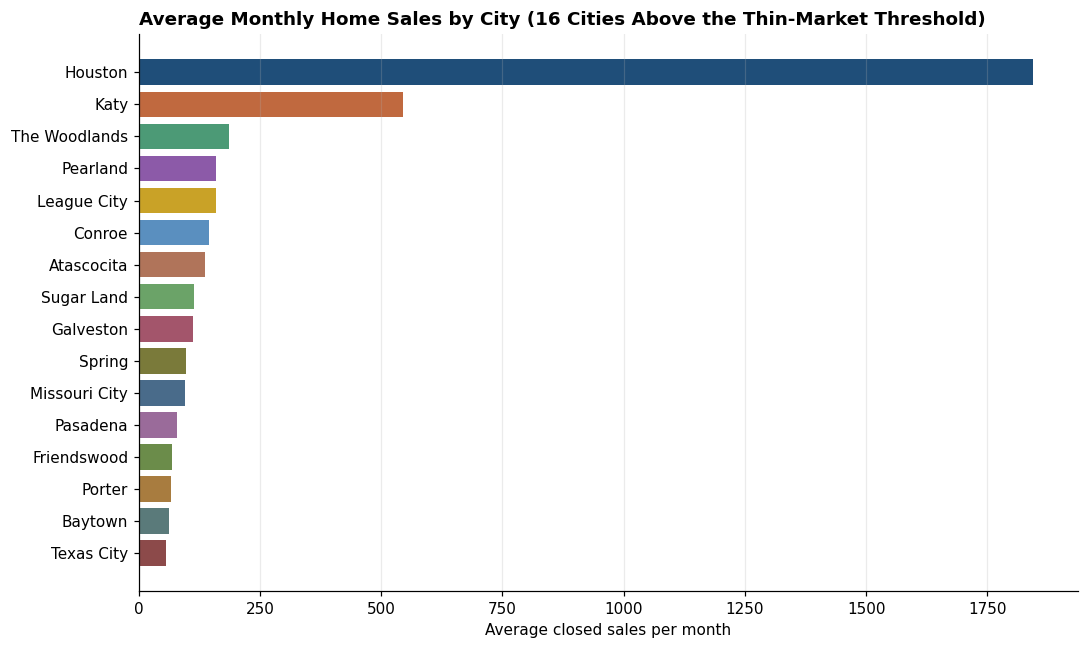

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
vals = main_cities_sorted.iloc[::-1]
colors = [CITY_COLORS.get(c, "#8c8c8c") for c in vals.index]
ax.barh(vals.index, vals.values, color=colors)
ax.set_title("Average Monthly Home Sales by City (16 Cities Above the Thin-Market Threshold)", fontsize=12, fontweight="bold", loc="left")
ax.set_xlabel("Average closed sales per month")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "25_city_sales_volume.png", dpi=150)
plt.show()

In [5]:
total_by_month = df.groupby("month")["closed_sales"].sum()
houston_by_month = df[df["city"] == "Houston"].set_index("month")["closed_sales"]
print(f"City of Houston's share of all metro-city sales volume: {(houston_by_month / total_by_month).mean():.1%}")

City of Houston's share of all metro-city sales volume: 37.0%


## 3. Price appreciation by city, indexed to a common start

Rebasing every city to 100 in its own first observed month makes cities at
very different price levels comparable on relative appreciation. Shown for
the 8 highest-volume reliable cities to keep the chart legible; all 16 are
in the underlying data.

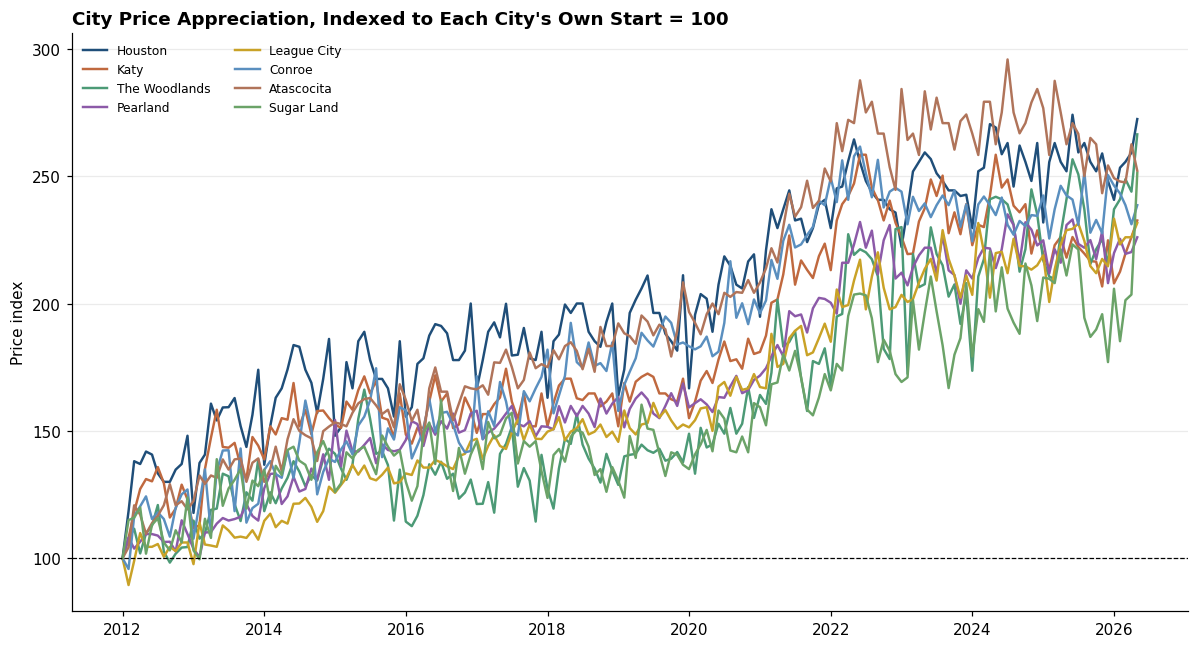

In [6]:
top8 = main_cities_sorted.index[:8].tolist()

fig, ax = plt.subplots(figsize=(11, 6))
for city in top8:
    sub = df[df["city"] == city]
    ax.plot(sub["month"], sub["price_index_2012_base100"], color=CITY_COLORS.get(city, "#8c8c8c"), linewidth=1.6, label=city)
ax.axhline(100, color="black", linewidth=0.8, linestyle="--")
ax.set_title("City Price Appreciation, Indexed to Each City's Own Start = 100", fontsize=12, fontweight="bold", loc="left")
ax.set_ylabel("Price index")
ax.legend(frameon=False, fontsize=8, ncol=2)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "26_city_price_index.png", dpi=150)
plt.show()

In [7]:
latest_index = df[(df["month"] == df["month"].max()) & (df["city"].isin(main_cities))]
latest_index = latest_index.set_index("city")["price_index_2012_base100"].sort_values(ascending=False)
latest_index.to_frame("price_index_2012_base100")

,price_index_2012_base100
city,
Texas City,369.9
Galveston,356.5
Spring,286.8
Houston,272.4
Pasadena,268.5
The Woodlands,266.4
Atascocita,252.1
Sugar Land,251.2
Baytown,242.5


## 4. Recent price and sales trend, most recent month vs. a year earlier

In [8]:
latest_month = df["month"].max()
year_ago = latest_month - pd.DateOffset(years=1)

recent = df[df["city"].isin(main_cities) & (df["month"] == latest_month)][
    ["city", "median_price", "months_inventory", "price_yoy_change", "sales_yoy_change"]
].sort_values("price_yoy_change", ascending=False).reset_index(drop=True)
recent

,city,median_price,months_inventory,price_yoy_change,sales_yoy_change
0,Sugar Land,567750.0,3.9,0.190751,-0.277311
1,The Woodlands,680000.0,2.3,0.105691,-0.068293
2,Galveston,381500.0,10.8,0.096264,-0.110092
3,Houston,367750.0,4.5,0.081618,-0.112512
4,Katy,360000.0,3.4,0.066667,-0.211949
5,Porter,300000.0,3.2,0.034483,-0.214286
6,Spring,255250.0,3.6,0.021409,-0.263158
7,League City,410000.0,3.0,0.012346,-0.146893
8,Missouri City,371000.0,4.2,0.002703,-0.008547
9,Pasadena,241375.0,2.9,-0.007912,0.123288


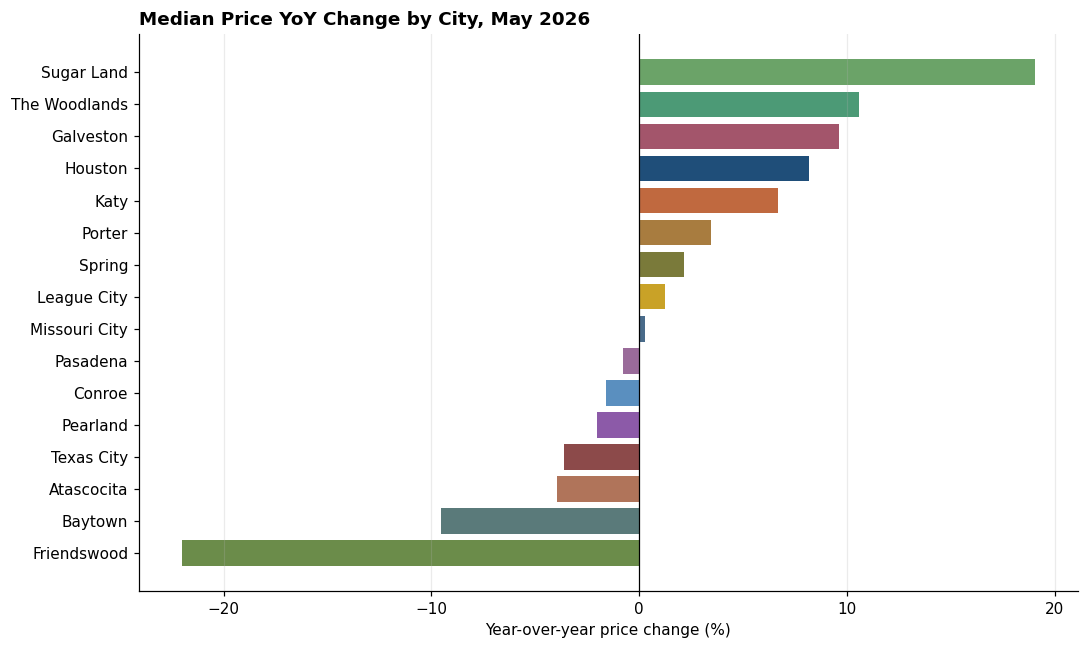

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = [CITY_COLORS.get(c, "#8c8c8c") for c in recent["city"]]
ax.barh(recent["city"][::-1], recent["price_yoy_change"][::-1] * 100, color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Median Price YoY Change by City, {latest_month.strftime('%B %Y')}", fontsize=12, fontweight="bold", loc="left")
ax.set_xlabel("Year-over-year price change (%)")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "27_city_yoy_price_change.png", dpi=150)
plt.show()

## 5. Inventory pressure by city: months of supply

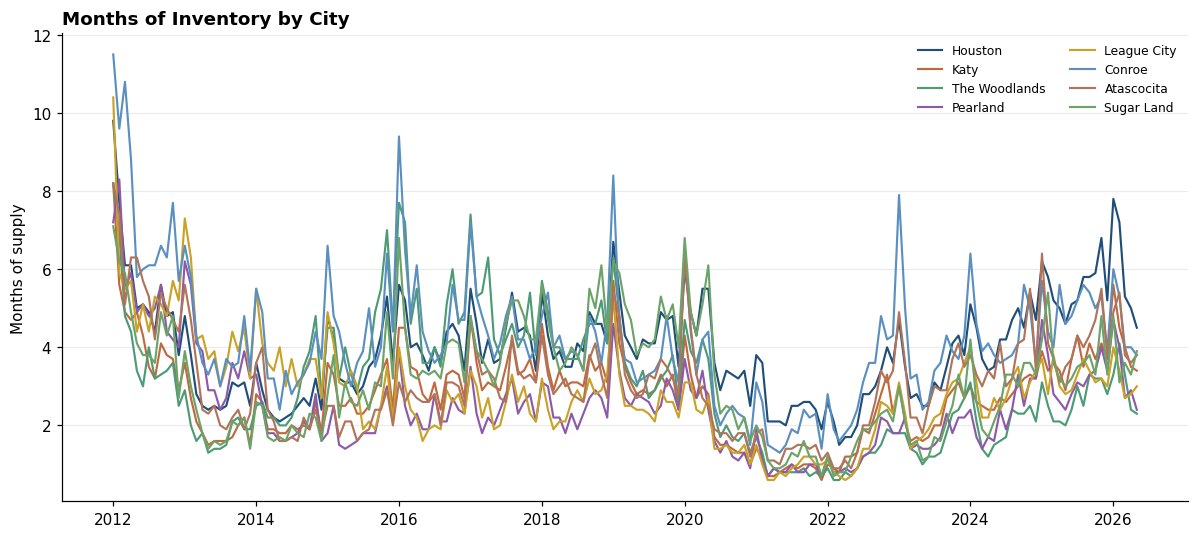

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
for city in top8:
    sub = df[df["city"] == city]
    ax.plot(sub["month"], sub["months_inventory"], color=CITY_COLORS.get(city, "#8c8c8c"), linewidth=1.4, label=city)
ax.set_title("Months of Inventory by City", fontsize=12, fontweight="bold", loc="left")
ax.set_ylabel("Months of supply")
ax.legend(frameon=False, fontsize=8, ncol=2)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "28_city_months_inventory.png", dpi=150)
plt.show()

## 6. Findings

- The city of Houston alone accounts for about 37% of total metro-city
  sales volume across all 165 tracked cities, more than three times the
  next-largest city (Katy) by average monthly sales. That's a large
  plurality, not a majority: the remaining 63% is spread across the other
  164 cities, most of them individually small.
- Of 165 cities Redfin tracks within the Houston metro, only 16 average at
  least 50 sales a month. The other 149, including some fairly well-known
  suburbs and communities, are too thin to read month-to-month without a
  real risk of the same small-sample distortion already seen at the county
  level (a handful of sales swinging a "median price" or "YoY change"
  substantially).
- Even among the 16 reliable cities, price appreciation and current
  inventory pressure vary meaningfully. This confirms, at a finer grain,
  the county-level finding that the metro number is not one uniform
  market: it holds even within a single county.
- City-level data does not change the metro-level or county-level
  conclusions from the earlier notebooks; it adds a finer-grained view for
  the specific cities with enough volume to support it.

## 7. Limitations

- 149 of 165 cities are flagged `thin_market` (average under 50 sales a
  month) and are excluded from every chart above, though they remain in
  the underlying CSV. Some of these nulls show up directly in the source
  data: Redfin itself does not always compute months-of-inventory or
  year-over-year figures for its thinnest markets.
- Same source limitations as v1 and the county dataset: non-seasonally-
  adjusted Redfin data, Redfin's own city boundary definitions (which do
  not always match municipal or Census-defined city limits), and revision
  risk on recent months.
- No causal claims. This notebook describes differences between cities; it
  does not explain why they exist.
- Full source detail: `data/source_notes.md`.